# 03 Exploratory Data Analysis (EDA)

Now that the data is clean, I can finally make some plots! I want to see how the total area for crops is changing over time and which states are doing the best.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style to make charts look professional
sns.set_style("whitegrid")

# Load the clean data
df = pd.read_csv("../data/processed/APY_cleaned.csv")
df.head()

,state,district,crop,crop_year,season,area,production,yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.399820
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.400025
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.737883
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660.0,0.641428
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,0.751264


## 1. Area usage over the years

Let's see if the total area is going up or down. A line chart is usually best for showing things over time.

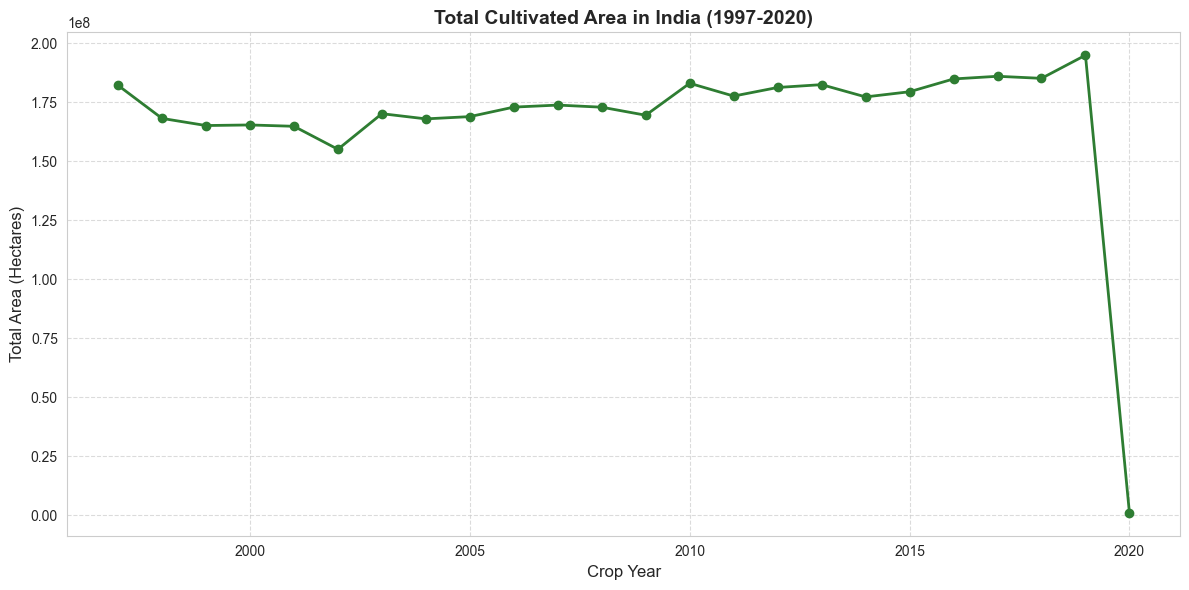

In [7]:
yearly_area = df.groupby('crop_year')['area'].sum()

plt.figure(figsize=(12, 6))
plt.plot(yearly_area.index, yearly_area.values, marker='o', linestyle='-', color='#2e7d32', linewidth=2)
plt.title('Total Cultivated Area in India (1997-2020)', fontsize=14, fontweight='bold')
plt.xlabel('Crop Year', fontsize=12)
plt.ylabel('Total Area (Hectares)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 2. Seasons

Which season has the most production? I'll use a bar chart here because it's easier to compare values than a pie chart.

/var/folders/rb/1t4bf5n12ygczx24mdpy0tc80000gq/T/ipykernel_20783/3802467729.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_prod.index, y=season_prod.values, palette='viridis')


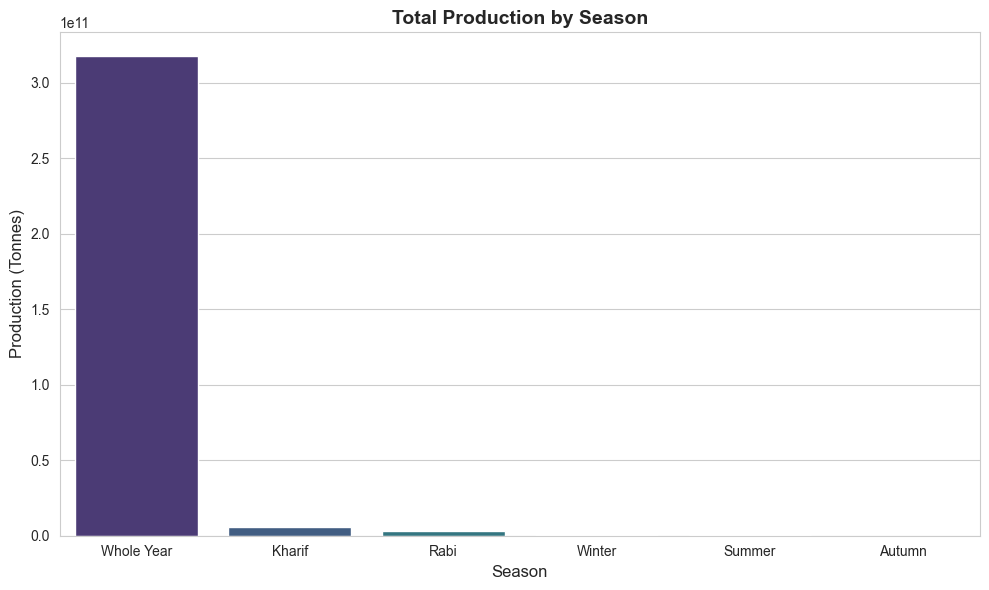

In [8]:
season_prod = df.groupby('season')['production'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=season_prod.index, y=season_prod.values, palette='viridis')
plt.title('Total Production by Season', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Production (Tonnes)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Best Crops

I'll look at the top 10 crops by total production. This helps identify the major food sources.

/var/folders/rb/1t4bf5n12ygczx24mdpy0tc80000gq/T/ipykernel_20783/374225633.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crops.values, y=top_crops.index, palette='magma')


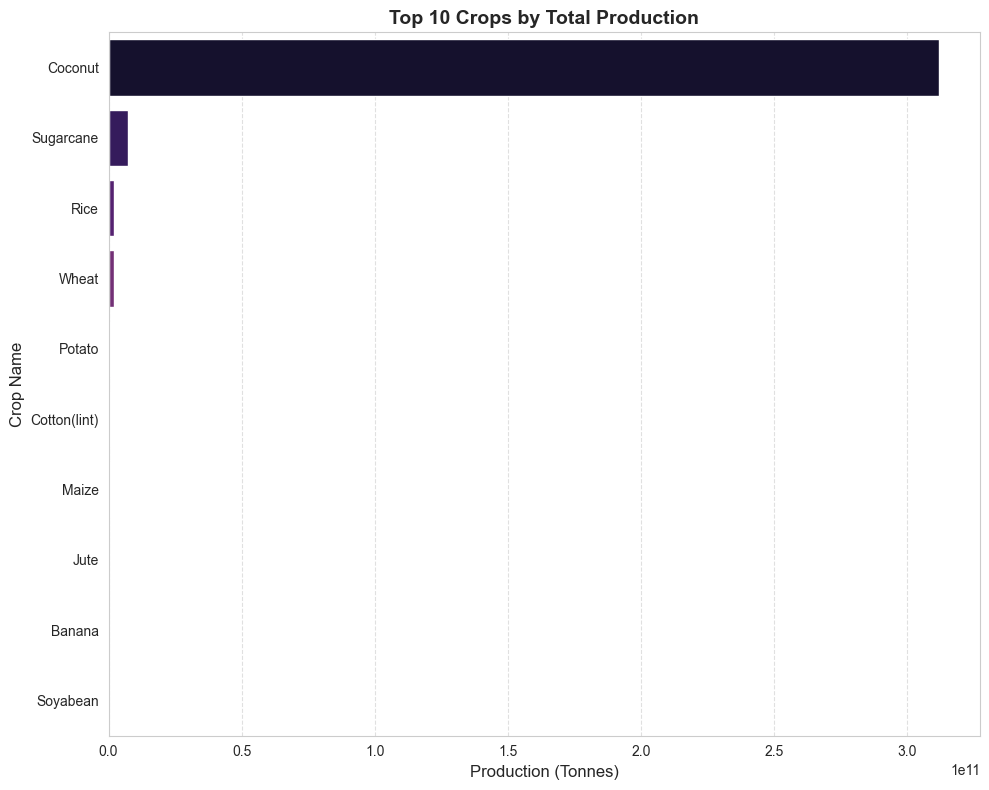

In [9]:
top_crops = df.groupby('crop')['production'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_crops.values, y=top_crops.index, palette='magma')
plt.title('Top 10 Crops by Total Production', fontsize=14, fontweight='bold')
plt.xlabel('Production (Tonnes)', fontsize=12)
plt.ylabel('Crop Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Best States by Yield

Now let's see which states have the highest average yield (efficiency).

/var/folders/rb/1t4bf5n12ygczx24mdpy0tc80000gq/T/ipykernel_20783/2548729752.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.values, y=top_states.index, palette='coolwarm')


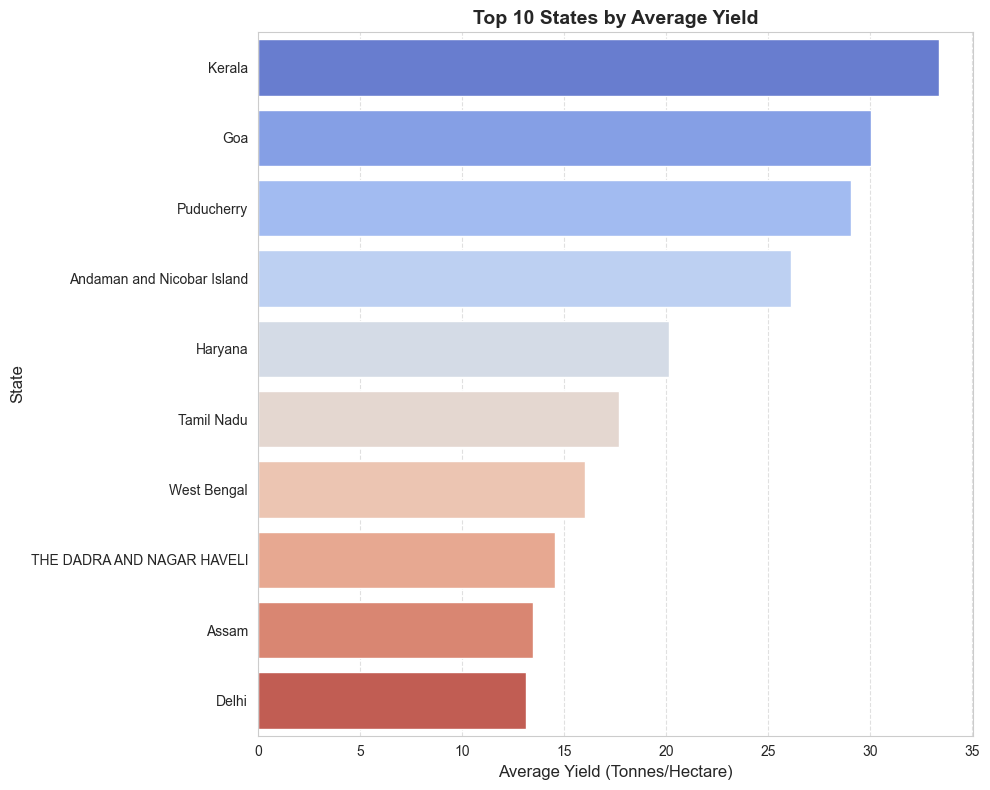

In [10]:
top_states = df.groupby('state')['yield'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_states.values, y=top_states.index, palette='coolwarm')
plt.title('Top 10 States by Average Yield', fontsize=14, fontweight='bold')
plt.xlabel('Average Yield (Tonnes/Hectare)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()